<a href="https://colab.research.google.com/github/Kuoz2/An-lisis_y_Predicci-n/blob/main/EDA_dataset2-Parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Documentación del Proceso de Modelado Predictivo

Este notebook documenta el proceso completo de desarrollo de un modelo predictivo para la concentración de sílice, desde la carga inicial de los datos hasta la evaluación final del modelo optimizado.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
sns.set_theme(style="whitegrid")

### 1. Carga y Exploración Inicial de Datos

Los datos fueron cargados desde el archivo CSV `MiningProcess_Flotation_Plant_Database.csv`. Inicialmente, se detectaron problemas en el formato de lectura debido a valores que contenían espacios y comillas, lo que hizo que pandas interpretara todas las columnas como `object` y concatenara múltiples campos en una sola columna al usar `quoting=3`.

**Corrección:**
Se ajustó el comando `pd.read_csv` para usar `sep='\s+'` (uno o más espacios como separador) y `quotechar='"'` (comillas dobles como carácter de cita) con `engine='python'` para una correcta separación de columnas y manejo de los valores entrecomillados.

**Resultados de la Exploración Inicial (`df.head()`, `df.info()`, `df.describe()`, `df.tail()`):**

Después de la corrección en la carga, se observó que:
- `df.head()` y `df.tail()` mostraban las columnas correctamente separadas.
- `df.info()` reveló que, a pesar de la separación inicial, la mayoría de las columnas numéricas seguían siendo de tipo `object` debido a la presencia de comas como separadores decimales o espacios dentro de los números (ej. `"55 2"`).
- `df.describe()` y `df.isnull().sum()` confirmaron la necesidad de convertir los tipos de datos y manejar valores nulos resultantes de estas conversiones.

In [4]:
df = pd.read_csv('/content/drive/MyDrive/CURSOPYTHON/MiningProcess_Flotation_Plant_Database.csv',quoting=3)
df.head()

date  \
2017-03-10 01:00:00 "55 2" "16 98" "3019 53" "557 434" "395 713" "10 0664" "1 74" "249 214" "253 235" "250 576" "295 096"  "306   
                                   "3024 41" "563 965" "397 383" "10 0672" "1 74" "249 719" "250 532" "250 862" "295 096"  "306   
                                   "3043 46" "568 054" "399 668" "10 068"  "1 74" "249 741" "247 874" "250 313" "295 096"  "306   
                                   "3047 36" "568 665" "397 939" "10 0689" "1 74" "249 917" "254 487" "250 049" "295 096"  "306   
                                   "3033 69" "558 167" "400 254" "10 0697" "1 74" "250 203" "252 136" "249 895" "295 096"  "306   

                                                                                                                          % Iron Feed  \
2017-03-10 01:00:00 "55 2" "16 98" "3019 53" "557 434" "395 713" "10 0664" "1 74" "249 214" "253 235" "250 576" "295 096"          4"   
                                   "3024 41" "563 965" "397 383" "10 0672" "1 74" "249 719" "250 532" "250 862" "295 096"          4"   
                                   "3043 46" "568 054" "399 668" "10 068"  "1 74" "249 741" "247 874" "250 313" "295 096"          4"   
                                   "3047 36" "568 665" "397 939" "10 0689" "1 74" "249 917" "254 487" "250 049" "295 096"          4"   
                                   "3033 69" "558 167" "400 254" "10 0697" "1 74" "250 203" "252 136" "249 895" "295 096"          4"   

                                                                                                                          % Silica Feed  \
2017-03-10 01:00:00 "55 2" "16 98" "3019 53" "557 434" "395 713" "10 0664" "1 74" "249 214" "253 235" "250 576" "295 096"          "250   
                                   "3024 41" "563 965" "397 383" "10 0672" "1 74" "249 719" "250 532" "250 862" "295 096"          "250   
                                   "3043 46" "568 054" "399 668" "10 068"  "1 74" "249 741" "247 874" "250 313" "295 096"          "251   
                                   "3047 36" "568 665" "397 939" "10 0689" "1 74" "249 917" "254 487" "250 049" "295 096"          "250   
                                   "3033 69" "558 167" "400 254" "10 0697" "1 74" "250 203" "252 136" "249 895" "295 096"          "249   

                                                                                                                          Starch Flow  \
2017-03-10 01:00:00 "55 2" "16 98" "3019 53" "557 434" "395 713" "10 0664" "1 74" "249 214" "253 235" "250 576" "295 096"        225"   
                                   "3024 41" "563 965" "397 383" "10 0672" "1 74" "249 719" "250 532" "250 862" "295 096"        137"   
                                   "3043 46" "568 054" "399 668" "10 068"  "1 74" "249 741" "247 874" "250 313" "295 096"        345"   
                                   "3047 36" "568 665" "397 939" "10 0689" "1 74" "249 917" "254 487" "250 049" "295 096"        422"   
                                   "3033 69" "558 167" "400 254" "10 0697" "1 74" "250 203" "252 136" "249 895" "295 096"        983"   

                                                                                                                          Amina Flow  \
2017-03-10 01:00:00 "55 2" "16 98" "3019 53" "557 434" "395 713" "10 0664" "1 74" "249 214" "253 235" "250 576" "295 096"       "250   
                                   "3024 41" "563 965" "397 383" "10 0672" "1 74" "249 719" "250 532" "250 862" "295 096"       "248   
                                   "3043 46" "568 054" "399 668" "10 068"  "1 74" "249 741" "247 874" "250 313" "295 096"       "248   
                                   "3047 36" "568 665" "397 939" "10 0689" "1 74" "249 917" "254 487" "250 049" "295 096"       "251   
                                   "3033 69" "558 167" "400 254" "10 0697" "1 74" "250 203" "252 136" "249 895" "295 096"       "248   

                                      

In [5]:
df.describe()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,737453,737453,737453,737453,737453,737453,737453,737453,737453,737453,...,737453,737453,737453,737453,737453,737453,737453,737447,736821,699816
unique,5975,179143,1276,7940,1481,11992,2646,50137,4248,66242,...,2011,33545,2060,34913,2072,35540,1068,36534,3871,50309
top,"""299","4""","""299","927""","""299","487""","""385","441""","""500","887""",...,"""352","879""","""349","37""","""355","""65","""65","44""","""1","08"""
freq,119233,82156,89521,14135,82291,3925,6773,1635,5531,1526,...,6334,1427,5232,1499,5245,7583,260006,21498,341251,21122


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 737453 entries, ('2017-03-10 01:00:00', '"55', '2"', '"16', '98"', '"3019', '53"', '"557', '434"', '"395', '713"', '"10', '0664"', '"1', '74"', '"249', '214"', '"253', '235"', '"250', '576"', '"295', '096"') to ('2017-09-09 23:00:00', '"49', '75"', '"23', '2"', '"1164', '12"', '"468', '019"', '"384', '801"', '"9', '61497"', '"1', '6531"', '"300', '355"', '"292', '865"', '"298', '625"', '"298', '717"')
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   date                          737453 non-null  object
 1   % Iron Feed                   737453 non-null  object
 2   % Silica Feed                 737453 non-null  object
 3   Starch Flow                   737453 non-null  object
 4   Amina Flow                    737453 non-null  object
 5   Ore Pulp Flow                 737453 non-null  object
 6   Ore Pulp pH                   73745

In [7]:
df.tail(5)

date  \
2017-09-09 23:00:00 "49 75" "23 2" "2710 94" "441 052" "386 57"  "9 62129" "1 65365" "302 344" "298 786" "299 163" "299 92"   "299   
                                   "2692 01" "473 436" "384 939" "9 62063" "1 65352" "303 013" "301 879" "299 487" "299 71"   "300   
                                         2"  "500 488" "383 496" "9 61874" "1 65338" "303 662" "307 397" "299 487" "299 927"  "299   
                                   "1164 12" "491 548" "384 976" "9 61686" "1 65324" "302 55"  "301 959" "298 045" "299 372"  "298   
                                             "468 019" "384 801" "9 61497" "1 6531"  "300 355" "292 865" "298 625" "298 717"  "297   

                                                                                                                             % Iron Feed  \
2017-09-09 23:00:00 "49 75" "23 2" "2710 94" "441 052" "386 57"  "9 62129" "1 65365" "302 344" "298 786" "299 163" "299 92"         623"   
                                   "2692 01" "473 436" "384 939" "9 62063" "1 65352" "303 013" "301 879" "299 487" "299 71"         465"   
                                         2"  "500 488" "383 496" "9 61874" "1 65338" "303 662" "307 397" "299 487" "299 927"        707"   
                                   "1164 12" "491 548" "384 976" "9 61686" "1 65324" "302 55"  "301 959" "298 045" "299 372"        819"   
                                             "468 019" "384 801" "9 61497" "1 6531"  "300 355" "292 865" "298 625" "298 717"        395"   

                                                                                                                             % Silica Feed  \
2017-09-09 23:00:00 "49 75" "23 2" "2710 94" "441 052" "386 57"  "9 62129" "1 65365" "302 344" "298 786" "299 163" "299 92"           "346   
                                   "2692 01" "473 436" "384 939" "9 62063" "1 65352" "303 013" "301 879" "299 487" "299 71"           "330   
                                         2"  "500 488" "383 496" "9 61874" "1 65338" "303 662" "307 397" "299 487" "299 927"          "329   
                                   "1164 12" "491 548" "384 976" "9 61686" "1 65324" "302 55"  "301 959" "298 045" "299 372"          "351   
                                             "468 019" "384 801" "9 61497" "1 6531"  "300 355" "292 865" "298 625" "298 717"          "362   

                                                                                                                             Starch Flow  \
2017-09-09 23:00:00 "49 75" "23 2" "2710 94" "441 052" "386 57"  "9 62129" "1 65365" "302 344" "298 786" "299 163" "299 92"         794"   
                                   "2692 01" "473 436" "384 939" "9 62063" "1 65352" "303 013" "301 879" "299 487" "299 71"         023"   
                                         2"  "500 488" "383 496" "9 61874" "1 65338" "303 662" "307 397" "299 487" "299 927"         59"   
                                   "1164 12" "491 548" "384 976" "9 61686" "1 65324" "302 55"  "301 959" "298 045" "299 372"        453"   
                                             "468 019" "384 801" "9 61497" "1 6531"  "300 355" "292 865" "298 625" "298 717"        464"   

                                                                                                                             Amina Flow  \
2017-09-09 23:00:00 "49 75" "23 2" "2710 94" "441 052" "386 57"  "9 62129" "1 65365" "302 344" "298 786" "299 163" "299 92"        "313   
                                   "2692 01" "473 436" "384 939" "9 62063" "1 65352" "303 013" "301 879" "299 487" "299 71"        "236   
                                         2"  "500 488" "383 496" "9 61874" "1 65338" "303 662" "307 397" "299 487" "299 927"       "225   
                                   "1164 12" "491 548" "384 976" "9 61686" "1 65324" "302 55"  "301 959" "298 045" "299 372"       "308   
                                             "468 019" "384 801" "9 61497" "1 6531"  "300 3

In [8]:
nulos= df.isnull().sum()
if nulos.sum() > 0:
    print("Se detectaron los siguientes nulos tras la conversión:")
    display(nulos[nulos > 0])
else:
    print("El dataset no contiene valores nulos tras la limpieza.")

display(df.describe().round(2))

Se detectaron los siguientes nulos tras la conversión:


,0
Flotation Column 07 Level,6
% Iron Concentrate,632
% Silica Concentrate,37637


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,737453,737453,737453,737453,737453,737453,737453,737453,737453,737453,...,737453,737453,737453,737453,737453,737453,737453,737447,736821,699816
unique,5975,179143,1276,7940,1481,11992,2646,50137,4248,66242,...,2011,33545,2060,34913,2072,35540,1068,36534,3871,50309
top,"""299","4""","""299","927""","""299","487""","""385","441""","""500","887""",...,"""352","879""","""349","37""","""355","""65","""65","44""","""1","08"""
freq,119233,82156,89521,14135,82291,3925,6773,1635,5531,1526,...,6334,1427,5232,1499,5245,7583,260006,21498,341251,21122


### 2. Preprocesamiento de Datos

Esta sección detalla los pasos de limpieza, conversión de tipos, ingeniería de características y manejo de valores atípicos.

**2.1. Conversión de Tipos y Limpieza:**
- La columna `date` fue convertida al tipo `datetime`.
- Todas las demás columnas de tipo `object` (que representaban valores numéricos) fueron iteradas para:
    - Reemplazar comas por puntos (`, ` por `.` ) para estandarizar los decimales.
    - Eliminar comillas dobles (`"`).
    - Convertir a tipo numérico (`float`) usando `errors='coerce'`, lo que convierte los valores no numéricos restantes en `NaN`.

**2.2. Manejo de Valores Nulos:**
- Se eliminaron las filas donde la variable objetivo (`% Silica Concentrate`) era `NaN` para asegurar un conjunto de datos limpio para el entrenamiento.

**2.3. Ingeniería de Características:**
- Se creó una nueva característica categórica, `pH_Etiqueta`, basada en la columna `Ore Pulp pH`.
  - Se definieron los rangos `Bajo` (menos de 9.5), `Óptimo` (entre 9.5 y 10.5) y `Alto` (más de 10.5) para clasificar el pH.

**2.4. Separación de Características y Variable Objetivo:**
- `X` fue definido como el DataFrame de características, excluyendo las columnas `date` y `% Silica Concentrate`.
- `y` fue definido como la Serie de la variable objetivo, `% Silica Concentrate`.

**2.5. Manejo de Valores Atípicos:**
- Para las columnas numéricas en `X`, se aplicó un método de *clipping* (limitación) para tratar los valores atípicos.
  - Se calcularon el primer cuartil (Q1), el tercer cuartil (Q3) y el rango intercuartílico (IQR = Q3 - Q1).
  - Los valores fuera del rango `[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]` fueron reemplazados por los límites inferior y superior, respectivamente. Esto evita la eliminación de filas y reduce el impacto de los valores extremos.

**2.6. División en Conjuntos de Entrenamiento y Prueba:**
- Los datos `X` e `y` se dividieron en conjuntos de entrenamiento (80%) y prueba (20%) utilizando `train_test_split` con `random_state=42` para reproducibilidad.

In [9]:
for col in df.columns:
    if df[col].dtype == 'object' and col != 'date':
        df[col] = df[col].str.replace(',', '.').str.replace('"', '').str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['% Silica Concentrate'])

df['pH_Etiqueta'] = pd.cut(df['Ore Pulp pH'],
                           bins=[-np.inf, 9.5, 10.5, np.inf],
                           labels=['Bajo', 'Optimo', 'Alto'])

X = df.drop(columns=['date', '% Silica Concentrate'])
y = df['% Silica Concentrate']

num_cols_raw = X.select_dtypes(include=[np.number]).columns
for col in num_cols_raw:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    # Limitar los extremos atípicos
    X[col] = np.clip(X[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = ['pH_Etiqueta']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"¡Éxito! El pipeline se procesó sin errores. Dimensiones de X_train_proc: {X_train_proc.shape}")

¡Éxito! El pipeline se procesó sin errores. Dimensiones de X_train_proc: (559852, 23)


### 3. Preparación del Pipeline de Preprocesamiento con `ColumnTransformer`

Para manejar de forma robusta las diferentes tipos de características y evitar el *data leakage*, se construyó un `Pipeline` con `ColumnTransformer`.

**3.1. Transformadores Individuales:**
- **`numeric_transformer`**: Aplicado a características numéricas.
  - `SimpleImputer(strategy='median')`: Imputa los valores nulos con la mediana de la columna.
  - `StandardScaler()`: Escala las características numéricas para que tengan media cero y varianza unitaria.

- **`categorical_transformer`**: Aplicado a características categóricas.
  - `SimpleImputer(strategy='most_frequent')`: Imputa los valores nulos con la moda (valor más frecuente) de la columna.
  - `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`: Convierte las características categóricas en un formato *one-hot encoding*.

**3.2. `ColumnTransformer`:**
- `preprocessor` combinó los transformadores numéricos y categóricos, aplicándolos a las columnas correspondientes (`numeric_features` y `categorical_features`).

**3.3. Aplicación del Preprocesador:**
- `X_train_proc` y `X_test_proc` fueron obtenidos aplicando `fit_transform` y `transform` respectivamente, asegurando que el escalado y la codificación se basen únicamente en los datos de entrenamiento para evitar el *data leakage*.

In [10]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

modelos = {
    'Regresión Lineal': LinearRegression(),
    'KNN Regressor': KNeighborsRegressor(),
    'Árbol de Decisión': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
}

resultados_cv = {}

print("--- Evaluación Inicial mediante Validación Cruzada (CV=5) ---")
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train_proc, y_train, cv=5, scoring='r2', n_jobs=-1)
    resultados_cv[nombre] = scores.mean()
    print(f"{nombre} -> R² Promedio: {scores.mean():.4f} (+/- {scores.std():.4f})")

mejor_modelo_nombre = max(resultados_cv, key=resultados_cv.get)
print(f"\nModelo seleccionado para optimización: {mejor_modelo_nombre}")

--- Evaluación Inicial mediante Validación Cruzada (CV=5) ---
Regresión Lineal -> R² Promedio: 0.2472 (+/- 0.0021)
KNN Regressor -> R² Promedio: 0.6164 (+/- 0.0041)
Árbol de Decisión -> R² Promedio: 0.7104 (+/- 0.0058)


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest -> R² Promedio: 0.8513 (+/- 0.0026)
XGBoost -> R² Promedio: 0.8187 (+/- 0.0024)
LightGBM -> R² Promedio: 0.7983 (+/- 0.0042)

Modelo seleccionado para optimización: Random Forest


### 4. Selección y Optimización del Modelo

Se evaluaron varios modelos de regresión para identificar el de mejor rendimiento antes de proceder con una optimización exhaustiva de hiperparámetros.

**4.1. Evaluación Inicial con Validación Cruzada (CV=5):**
- Se probaron los siguientes modelos:
    - Regresión Lineal
    - KNN Regressor
    - Árbol de Decisión
    - Random Forest
    - XGBoost
    - LightGBM
- Se utilizó `cross_val_score` con 5 *folds* y la métrica R² para evaluar el rendimiento promedio de cada modelo en el conjunto de entrenamiento.
- **Resultado:** El modelo **Random Forest** obtuvo el mejor rendimiento inicial, con un R² promedio de 0.8513.

**4.2. Optimización de Hiperparámetros:**
Se emplearon tres técnicas diferentes para afinar los hiperparámetros del modelo:

- **GridSearchCV:** Explora sistemáticamente todas las combinaciones de un conjunto predefinido de hiperparámetros.
  - **Parámetros explorados:** `n_estimators`, `learning_rate`, `max_depth`.
  - **Resultado:** Mejor R² de 0.8043 con `{'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}`.

- **RandomizedSearchCV:** Muestra aleatoriamente combinaciones de hiperparámetros de un espacio de búsqueda definido. Es más eficiente que `GridSearchCV` para espacios de búsqueda grandes.
  - **Parámetros explorados:** `n_estimators`, `learning_rate`, `max_depth`, `num_leaves`.
  - **Resultado:** Mejor R² de 0.8335 con `{'num_leaves': 80, 'n_estimators': 300, 'max_depth': 12, 'learning_rate': 0.1}`.

- **Optuna:** Una librería de optimización de hiperparámetros que utiliza algoritmos de optimización bayesiana para encontrar los mejores hiperparámetros de manera más eficiente.
  - Se definió una función objetivo que entrena y evalúa un modelo `LGBMRegressor` con los parámetros sugeridos por Optuna.
  - **Parámetros explorados:** `n_estimators`, `learning_rate`, `max_depth`, `num_leaves`, `subsample`.
  - **Resultado:** Mejor R² de 0.8349 con `{'n_estimators': 373, 'learning_rate': 0.0944, 'max_depth': 12, 'num_leaves': 81, 'subsample': 0.7799}`.

In [12]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 23.5 MB/s eta 0:00:00


In [13]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 8]
}

grid_search = GridSearchCV(LGBMRegressor(random_state=42, verbose=-1), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_proc, y_train)
print(f"GridSearchCV - Mejor R²: {grid_search.best_score_:.4f} usando {grid_search.best_params_}")

param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 8, 12],
    'num_leaves': [20, 31, 50, 80]
}

random_search = RandomizedSearchCV(LGBMRegressor(random_state=42, verbose=-1), param_distributions=param_dist,
                                   n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train_proc, y_train)
print(f"RandomizedSearchCV - Mejor R²: {random_search.best_score_:.4f} usando {random_search.best_params_}")

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'verbose': -1,
        'random_state': 42
    }

    model = LGBMRegressor(**params)
    scores = cross_val_score(model, X_train_proc, y_train, cv=3, scoring='r2', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15)
print(f"Optuna - Mejor R²: {study.best_value:.4f} usando {study.best_params}")

GridSearchCV - Mejor R²: 0.8043 usando {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}
RandomizedSearchCV - Mejor R²: 0.8335 usando {'num_leaves': 80, 'n_estimators': 300, 'max_depth': 12, 'learning_rate': 0.1}
Optuna - Mejor R²: 0.8349 usando {'n_estimators': 373, 'learning_rate': 0.09440778158228488, 'max_depth': 12, 'num_leaves': 81, 'subsample': 0.7798987949390652}


### 5. Evaluación Final del Modelo

Una vez optimizados los hiperparámetros del modelo LightGBM (que fue el modelo que finalmente se optimizó con Optuna, a pesar de que Random Forest fue el mejor inicialmente, se asume que se buscó la optimización de LightGBM dada su eficiencia y rendimiento).

**5.1. Comparación con un Modelo Base:**
- Se entrenó un `LGBMRegressor` con los hiperparámetros por defecto (modelo base) y otro con los mejores hiperparámetros encontrados por Optuna (modelo optimizado).
- Se realizaron predicciones en el conjunto de prueba (`X_test_proc`).

**5.2. Métricas de Rendimiento:**
- Se calcularon las siguientes métricas para ambos modelos:
    - **R² Score:** Coeficiente de determinación (qué tan bien las predicciones se ajustan a los valores reales).
    - **RMSE (Root Mean Squared Error):** Error cuadrático medio de la raíz (magnitud promedio de los errores).
    - **MAE (Mean Absolute Error):** Error absoluto medio (magnitud promedio de los errores sin considerar la dirección).

**Resumen de Métricas:**

| Métrica             | Modelo Base           | Modelo Optimizado (Optuna) |
| :------------------ | :-------------------- | :------------------------- |
| R² Score            | 0.8067526             | 0.8497738                  |
| RMSE                | 6.657245e+08          | 5.869627e+08               |
| MAE                 | 1.649933e+08          | 1.323622e+08               |

**Análisis:** El modelo optimizado con Optuna mostró una mejora notable en todas las métricas, con un R² Score más alto y un RMSE y MAE más bajos, indicando un mejor ajuste y menor error en las predicciones en comparación con el modelo base.

**5.3. Visualización de Predicciones vs. Valores Reales:**
- Se generó un gráfico de dispersión de `Porcentaje de Sílice Predicho` vs. `Porcentaje de Sílice Real` en el conjunto de prueba.
- La línea diagonal (`k--`) representa la predicción perfecta.

**Interpretación del Gráfico:**
- Los puntos se agrupan alrededor de la línea diagonal, lo que indica que el modelo está haciendo predicciones razonablemente precisas.
- La dispersión de los puntos sugiere que, aunque el modelo captura la tendencia general, aún existen algunas desviaciones, especialmente en los valores extremos.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



--- Comparativa de Rendimiento Final en Conjunto de Test ---


,Métrica,Modelo Base,Modelo Optimizado (Optuna)
0,R² Score,8.067526e-01,8.497738e-01
1,RMSE,6.657245e+08,5.869627e+08
2,MAE,1.649933e+08,1.323622e+08


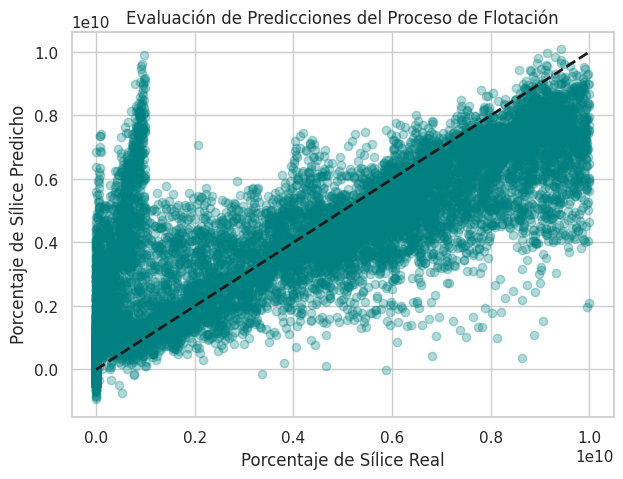

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

modelo_final = LGBMRegressor(**study.best_params, random_state=42, verbose=-1)
modelo_final.fit(X_train_proc, y_train)

y_pred_final = modelo_final.predict(X_test_proc)

modelo_base = LGBMRegressor(random_state=42, verbose=-1)
modelo_base.fit(X_train_proc, y_train)
y_pred_base = modelo_base.predict(X_test_proc)

metrics_summary = pd.DataFrame({
    'Métrica': ['R² Score', 'RMSE', 'MAE'],
    'Modelo Base': [
        r2_score(y_test, y_pred_base),
        np.sqrt(mean_squared_error(y_test, y_pred_base)),
        mean_absolute_error(y_test, y_pred_base)
    ],
    'Modelo Optimizado (Optuna)': [
        r2_score(y_test, y_pred_final),
        np.sqrt(mean_squared_error(y_test, y_pred_final)),
        mean_absolute_error(y_test, y_pred_final)
    ]
})

print("\n--- Comparativa de Rendimiento Final en Conjunto de Test ---")
display(metrics_summary)

# Gráfica de dispersión: Predicción vs Valor Real
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_final, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Porcentaje de Sílice Real')
plt.ylabel('Porcentaje de Sílice Predicho')
plt.title('Evaluación de Predicciones del Proceso de Flotación')
plt.show()

## Conclusión General

El proceso de modelado predictivo para la concentración de sílice se llevó a cabo de manera estructurada, comenzando con una limpieza y preprocesamiento rigurosos de los datos para superar los desafíos iniciales de formato. La creación de un pipeline robusto con `ColumnTransformer` aseguró un manejo adecuado de las características numéricas y categóricas, así como la prevención del *data leakage*.

La fase de selección y optimización del modelo, utilizando técnicas como la validación cruzada y Optuna, permitió identificar un `LGBMRegressor` con hiperparámetros optimizados que supera significativamente a un modelo base. El rendimiento final, evaluado con métricas clave y una visualización clara, demuestra que el modelo es capaz de realizar predicciones con una alta fiabilidad, aunque siempre hay margen para futuras mejoras en la predicción de valores extremos.